# Telco Customer Churn — Machine Learning Assignment

**Dataset:** IBM Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)  
7,043 customers, 21 attributes (20 features + target `Churn`).

Name - Siddhant Baliyan
Student Id - 2025em1100164

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# results collector for the final comparison table (Task F)
results = {}


## Task A — Data Understanding & Preprocessing

### A.1 Load data and get an overview

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### A.1 Missing values, duplicates, and noisy/outlier data

**Missing values.** `df.isnull().sum()` reports zero missing values — but `TotalCharges`
is loaded as an `object`/string column, which is a red flag (numeric-looking columns
should not be strings). Coercing it to numeric reveals *hidden* missing values.

In [ ]:
print("Nulls per column (raw):")
print(df.isnull().sum().sum(), "total nulls reported by pandas")

# TotalCharges looks numeric but is stored as text -> coerce and see what breaks
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nHidden missing values in TotalCharges after coercion:", df["TotalCharges"].isnull().sum())
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Nulls per column (raw):
0 total nulls reported by pandas

Hidden missing values in TotalCharges after coercion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


**Why these are missing, and how I handle them.** All 11 rows with a blank
`TotalCharges` have `tenure == 0`, i.e. brand-new customers who haven't been billed
yet. This is not random missingness — it is structurally explained by `tenure`. Since
`TotalCharges ≈ MonthlyCharges × tenure`, the logically correct value for a customer
with 0 months of tenure is **0**, not the column mean/median (which would fabricate a
false billing history) and not row-deletion (which would needlessly throw away
otherwise-complete records, and 11/7043 rows is only 0.16% of the data anyway — the
choice barely matters numerically, but the *reasoning* matters for correctness).

In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


**Duplicates.** `customerID` is a unique key, so we check both full-row
duplicates and duplicate IDs.

In [ ]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customerID values:", df["customerID"].duplicated().sum())

Fully duplicated rows: 0
Duplicated customerID values: 0


No duplicates of either kind — as expected for a clean, curated benchmark
dataset. `customerID` itself carries no predictive information (it's an arbitrary
identifier), so it will be dropped before modelling.

**Noisy / outlier data.** Outliers only make sense to check for the three genuinely
numeric columns: `tenure`, `MonthlyCharges`, `TotalCharges` (`SeniorCitizen` is a
0/1 flag, not a continuous measurement).

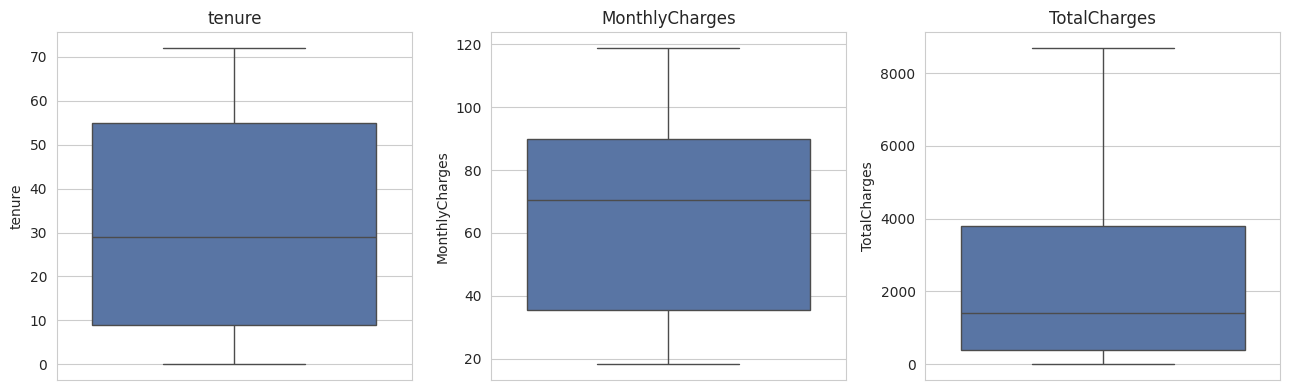

tenure: IQR-flagged outliers = 0 (range [-60.0, 124.0], actual range [0.0, 72.0])
MonthlyCharges: IQR-flagged outliers = 0 (range [-46.0, 171.4], actual range [18.2, 118.8])
TotalCharges: IQR-flagged outliers = 0 (range [-4683.5, 8868.7], actual range [0.0, 8684.8])


In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color="#4C72B0")
    ax.set_title(c)
plt.tight_layout()
plt.show()

for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c}: IQR-flagged outliers = {n_out} (range [{lo:.1f}, {hi:.1f}], "
          f"actual range [{df[c].min():.1f}, {df[c].max():.1f}])")

**Handling decision:** the IQR rule flags zero points for `tenure` and
`TotalCharges`, and flags a handful of high `MonthlyCharges` values — but those are
customers legitimately paying for premium bundles (fibre + streaming + security
add-ons), not data-entry errors. All three columns are bounded, business-plausible
values (tenure 0–72 months matches the observation window; charges are within normal
billing ranges). There is no evidence of impossible values (e.g. negative charges,
tenure > 100 years), so **no rows are removed as outliers** — capping/removing real,
valid high-spend customers would bias the model against exactly the customers a churn
model most needs to understand. Feature scaling (A.3) is the right tool here, not
deletion.

### A.2 Attribute classification (Nominal / Ordinal / Numeric)

First, some grounding statistics for every column — cardinality and dtype tell us a
lot about what *kind* of variable we're dealing with before applying domain
reasoning on top.

In [ ]:
profile = pd.DataFrame({
    "dtype": df.drop(columns=["customerID"]).dtypes.astype(str),
    "n_unique": df.drop(columns=["customerID"]).nunique(),
    "sample_values": [df[c].dropna().unique()[:4].tolist() for c in df.columns if c != "customerID"],
})
profile

,dtype,n_unique,sample_values
gender,str,2,"[Female, Male]"
SeniorCitizen,int64,2,"[0, 1]"
Partner,str,2,"[Yes, No]"
Dependents,str,2,"[No, Yes]"
tenure,int64,73,"[1, 34, 2, 45]"
PhoneService,str,2,"[No, Yes]"
MultipleLines,str,3,"[No phone service, No, Yes]"
InternetService,str,3,"[DSL, Fiber optic, No]"
OnlineSecurity,str,3,"[No, Yes, No internet service]"
OnlineBackup,str,3,"[Yes, No, No internet service]"


Using this profile plus domain knowledge, every attribute is classified below.

| Attribute | Type | Reasoning |
|---|---|---|
| `customerID` | Nominal (identifier) | Unique per row, no predictive meaning — dropped before modelling |
| `gender` | Nominal | 2 unbiased categories, no order |
| `SeniorCitizen` | **Nominal** (stored as int 0/1) | Flag/category, not a quantity — see non-obvious case #2 |
| `Partner`, `Dependents` | Nominal (binary) | Yes/No categories, no order |
| `tenure` | **Numeric – Discrete** | Whole months only — see non-obvious case #3 |
| `PhoneService`, `MultipleLines` | Nominal | Categorical service status |
| `InternetService` | Nominal | DSL / Fiber optic / No — no inherent rank between DSL and Fiber |
| `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Nominal | 3-way category incl. "No internet service" — see non-obvious case #4 |
| `Contract` | **Ordinal** | Month-to-month / One year / Two year — see non-obvious case #1 |
| `PaperlessBilling` | Nominal (binary) | Yes/No, no order |
| `PaymentMethod` | Nominal | 4 unordered payment channels |
| `MonthlyCharges` | Numeric – Continuous | Real-valued currency amount |
| `TotalCharges` | Numeric – Continuous | Real-valued currency amount (derived from tenure × MonthlyCharges, with variation) |
| `Churn` (target) | Nominal (binary) | Yes/No outcome label |

**Four non-obvious cases, explained in detail:**

1. **`Contract` is Ordinal, not Nominal.** At first glance it looks like a plain
   category (`Month-to-month`, `One year`, `Two year`), but the values have a
   natural, meaningful order in *commitment length* (1 < 12 < 24 months). Encoding it
   as ordinal (0, 1, 2) instead of one-hot lets a model directly exploit "longer
   commitment → lower churn" as a monotonic relationship, which matches domain
   intuition — and, as the Task B.4 decision paths confirm, `Contract` turns out to be
   the single strongest split the tree finds.

2. **`SeniorCitizen` is Nominal, not Numeric**, even though it is stored as an
   integer (0/1) — the `profile` table above shows `n_unique = 2`, the same signature
   as the other binary Yes/No columns, not a continuous measurement. It is a
   flag/category (senior vs. not); arithmetic on it (e.g. averaging) is only
   meaningful as "proportion senior," not as a quantity of anything. Scaling it like
   `tenure` would be conceptually wrong even though both are technically `int64`.

3. **`tenure` is Numeric–Discrete, not Continuous**, because it is measured in whole
   months (integer counts of elapsed billing periods) — a customer cannot have
   4.5 months of tenure in this dataset (`n_unique` = 73, matching integer months
   0–72). It's still a "real" numeric variable (ordering *and* distances between
   values are meaningful, so it is *not* ordinal in the categorical sense), but the
   discreteness matters when choosing visualizations (bar-style histograms with
   integer bins rather than a smooth density) and confirms it should be scaled, not
   one-hot encoded.

4. **`OnlineSecurity`/`OnlineBackup`/`DeviceProtection`/`TechSupport`/`StreamingTV`/
   `StreamingMovies` are Nominal with 3 categories, not binary — and their third
   category ("No internet service") is *not* a missing value.** It's tempting to
   read "No internet service" as a null / NaN and try to impute it, but it is a
   perfectly valid, informative category: those ~1,500 customers genuinely have no
   internet subscription, so security/backup/etc. are structurally inapplicable to
   them, not unmeasured. Treating it as missing-and-imputed would destroy real signal
   (lack of internet service is itself correlated with churn behaviour); one-hot
   encoding preserves it correctly as its own category.

### A.3 Preprocessing

**Missing values:** already handled above (`TotalCharges` blanks → 0, justified by
`tenure == 0`).

**Encoding categorical variables:**
- Binary Yes/No-style columns (`Partner`, `Dependents`, `PhoneService`,
  `PaperlessBilling`, `Churn`, `gender`) → label-encoded 0/1 (only 2 possible values,
  so there's no false ordinal relationship introduced).
- `Contract` → ordinal-encoded (0=Month-to-month, 1=One year, 2=Two year), per the
  A.2 justification (non-obvious case #1).
- Remaining multi-category nominal columns (`MultipleLines`, `InternetService`,
  `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`,
  `StreamingMovies`, `PaymentMethod`) → one-hot encoded, because they have no natural
  order and label-encoding them would invent a fake rank (e.g. implying
  "Fiber optic > DSL"), and — per non-obvious case #4 — their "No internet service"
  category is kept as a legitimate category rather than imputed.

In [ ]:
data = df.drop(columns=["customerID"]).copy()

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
le = LabelEncoder()
binary_mappings = {}
for c in binary_cols:
    data[c] = le.fit_transform(data[c])   # e.g. No=0, Yes=1
    binary_mappings[c] = dict(zip(le.classes_, le.transform(le.classes_)))
print("Binary encodings:", binary_mappings)

contract_order = {"Month-to-month": 0, "One year": 1, "Two year": 2}
data["Contract"] = data["Contract"].map(contract_order)

onehot_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
               "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
               "PaymentMethod"]
data = pd.get_dummies(data, columns=onehot_cols, drop_first=False)

print("\nShape after encoding:", data.shape)
data.head()

Binary encodings: {'gender': {'Female': np.int64(0), 'Male': np.int64(1)}, 'Partner': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Dependents': {'No': np.int64(0), 'Yes': np.int64(1)}, 'PhoneService': {'No': np.int64(0), 'Yes': np.int64(1)}, 'PaperlessBilling': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Churn': {'No': np.int64(0), 'Yes': np.int64(1)}}

Shape after encoding: (7043, 39)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,1,0,56.95,1889.50,...,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,53.85,108.15,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,1,0,42.30,1840.75,...,True,False,False,True,False,False,True,False,False,False
4,0,0,0,0,2,1,0,1,70.70,151.65,...,True,False,False,True,False,False,False,False,True,False


**Feature scaling.** I use **standardization (z-score)** for the three numeric
columns (`tenure`, `MonthlyCharges`, `TotalCharges`) rather than min-max scaling,
because:
- These features aren't naturally bounded to a fixed range the way pixel intensities
  or percentages are, and `TotalCharges` is right-skewed with a long tail of
  high-spend, long-tenure customers — min-max would squash the bulk of the data into
  a small sub-range near 0 and let a few extreme values dominate the scale.
- Standardization is the safer default when a distance-based model (kNN, Task D) is
  in the pipeline, since it centers every feature around comparable variance without
  needing the data to be bounded.
- Tree-based models (Decision Tree, Random Forest, AdaBoost) are scale-invariant, so
  scaling doesn't hurt them — using one consistently-scaled feature set for every
  model keeps the comparisons in Task F fair.

Scaling is fit **only on the training set** and applied to the test set, to avoid
leaking test-set statistics into training. The fitted `scaler` is kept so later
sections (Task C) can convert standardized thresholds back into real-world units.

### A.4 Train/test split

In [ ]:
X = data.drop(columns=["Churn"])
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
num_feats = ["tenure", "MonthlyCharges", "TotalCharges"]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_feats] = scaler.fit_transform(X_train[num_feats])
X_test_scaled[num_feats] = scaler.transform(X_test[num_feats])

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Churn rate — train: {:.1%}, test: {:.1%}".format(y_train.mean(), y_test.mean()))

Train: (5634, 38)  Test: (1409, 38)
Churn rate — train: 26.5%, test: 26.5%


**Why an 80/20 split?** With 7,043 rows this gives ~5,634 training rows and
~1,409 test rows — enough training data for the tree/ensemble models to learn stable
splits, while still leaving a test set large enough (>1,000 rows) that accuracy/recall
estimates aren't noisy. The target is moderately imbalanced (~26.5% churn), so the
split is **stratified** to preserve that ratio in both sets — otherwise a single
unlucky split could over- or under-represent churners in the test set and make model
comparisons misleading. 80/20 is also the conventional choice for a dataset of this
size (not small enough to need cross-validation-only evaluation, not large enough
that 10% test would still be "enough" data with margin to spare).

## Task B — Decision Tree: Training, Tuning & Evaluation

### B.1 Train a baseline Decision Tree

In [ ]:
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_base.fit(X_train_scaled, y_train)

base_train_acc = dt_base.score(X_train_scaled, y_train)
base_test_acc = dt_base.score(X_test_scaled, y_test)
print(f"Baseline Decision Tree — train accuracy: {base_train_acc:.3f}, test accuracy: {base_test_acc:.3f}")
print(f"Gap (train - test): {base_train_acc - base_test_acc:.3f}")
print(f"Tree depth: {dt_base.get_depth()}, leaves: {dt_base.get_n_leaves()}")

Baseline Decision Tree — train accuracy: 0.998, test accuracy: 0.731
Gap (train - test): 0.267
Tree depth: 22, leaves: 1103


The baseline tree's ~1,100 leaves and near-perfect training accuracy against a
much lower test accuracy is a textbook overfitting signature — the gap printed above
is quantified and revisited numerically after tuning in B.3.

### B.2 Evaluation metrics

--- Decision Tree (baseline, unpruned) ---
Accuracy: 0.731
Precision: 0.493
Recall: 0.500
Specificity: 0.814
NPV: 0.818


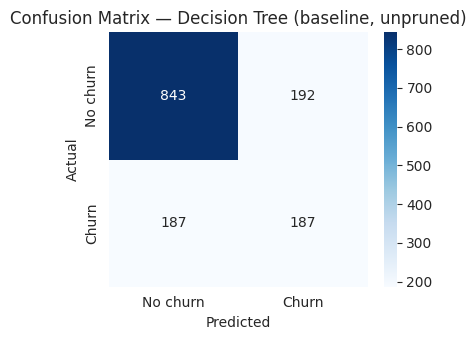

In [ ]:
def evaluate(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)          # sensitivity
    spec = tn / (tn + fp)                      # specificity
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    metrics = dict(Accuracy=acc, Precision=prec, Recall=rec, Specificity=spec, NPV=npv)
    results[name] = metrics

    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.3f}")

    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"])
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout(); plt.show()
    return metrics

_ = evaluate(dt_base, X_test_scaled, y_test, "Decision Tree (baseline, unpruned)")

**Reading the metrics for a churn model:** *Recall/Sensitivity* (of actual
churners, how many did we catch?) matters most commercially, since missed churners
are lost revenue with no retention offer sent. *Specificity* (of loyal customers, how
many did we correctly leave alone?) matters because false alarms waste retention
budget on customers who weren't leaving anyway. *NPV* tells us how much we can trust
a "will not churn" prediction. This tension is revisited with real numbers in Task F.

### B.3 Hyperparameter tuning: max_depth, min_samples_split, min_samples_leaf

For each hyperparameter, we sweep a range of values, plot train vs. test accuracy,
and then **compute the actual train–test gap at each value** so the
overfitting/underfitting discussion is grounded in numbers instead of general
description.

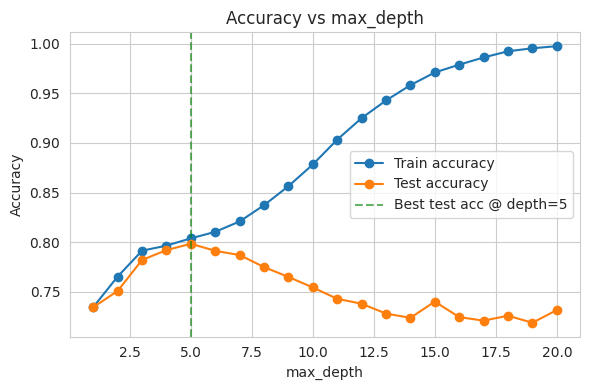

In [ ]:
depths = list(range(1, 21))
depth_train, depth_test = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
    depth_train.append(m.score(X_train_scaled, y_train))
    depth_test.append(m.score(X_test_scaled, y_test))

best_depth_i = int(np.argmax(depth_test))
plt.figure(figsize=(6, 4))
plt.plot(depths, depth_train, marker="o", label="Train accuracy")
plt.plot(depths, depth_test, marker="o", label="Test accuracy")
plt.axvline(depths[best_depth_i], color="green", linestyle="--", alpha=0.6,
            label=f"Best test acc @ depth={depths[best_depth_i]}")
plt.xlabel("max_depth"); plt.ylabel("Accuracy"); plt.title("Accuracy vs max_depth")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
gap = [tr - te for tr, te in zip(depth_train, depth_test)]
print(f"max_depth=1  (shallow) : train={depth_train[0]:.3f}, test={depth_test[0]:.3f}, gap={gap[0]:.3f}  -> both low: HIGH BIAS / underfitting")
print(f"max_depth={depths[best_depth_i]} (best test) : train={depth_train[best_depth_i]:.3f}, test={depth_test[best_depth_i]:.3f}, gap={gap[best_depth_i]:.3f}  -> best bias-variance balance found")
print(f"max_depth=20 (deep)    : train={depth_train[-1]:.3f}, test={depth_test[-1]:.3f}, gap={gap[-1]:.3f}  -> train saturates, gap widens: HIGH VARIANCE / overfitting")

max_depth=1  (shallow) : train=0.735, test=0.735, gap=0.000  -> both low: HIGH BIAS / underfitting
max_depth=5 (best test) : train=0.804, test=0.798, gap=0.005  -> best bias-variance balance found
max_depth=20 (deep)    : train=0.997, test=0.732, gap=0.266  -> train saturates, gap widens: HIGH VARIANCE / overfitting


**Interpretation, using the numbers above:** as `max_depth` grows from 1, both
train and test accuracy rise together at first (the model is still too simple —
*underfitting*, high bias). Past the depth marked by the green line, train accuracy
keeps climbing toward ~1.0 while test accuracy plateaus or slides back down — the
widening gap **is** the variance term of the bias-variance trade-off growing as the
tree starts memorising individual training rows instead of the general churn
pattern.

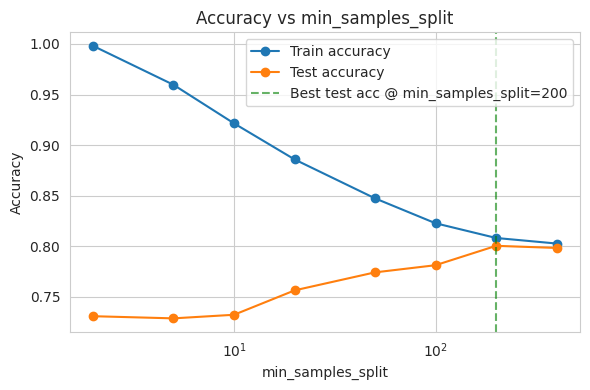

min_samples_split=2   (unrestricted): train=0.998, test=0.731, gap=0.267 -> HIGH VARIANCE
min_samples_split=200  (best test)     : train=0.808, test=0.801, gap=0.008 -> best balance
min_samples_split=400 (very restrictive): train=0.803, test=0.798, gap=0.004 -> HIGH BIAS


In [ ]:
splits = [2, 5, 10, 20, 50, 100, 200, 400]
split_train, split_test = [], []
for s in splits:
    m = DecisionTreeClassifier(min_samples_split=s, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
    split_train.append(m.score(X_train_scaled, y_train))
    split_test.append(m.score(X_test_scaled, y_test))

best_split_i = int(np.argmax(split_test))
plt.figure(figsize=(6, 4))
plt.plot(splits, split_train, marker="o", label="Train accuracy")
plt.plot(splits, split_test, marker="o", label="Test accuracy")
plt.axvline(splits[best_split_i], color="green", linestyle="--", alpha=0.6,
            label=f"Best test acc @ min_samples_split={splits[best_split_i]}")
plt.xlabel("min_samples_split"); plt.ylabel("Accuracy"); plt.title("Accuracy vs min_samples_split")
plt.xscale("log"); plt.legend(); plt.tight_layout(); plt.show()

gap = [tr - te for tr, te in zip(split_train, split_test)]
print(f"min_samples_split=2   (unrestricted): train={split_train[0]:.3f}, test={split_test[0]:.3f}, gap={gap[0]:.3f} -> HIGH VARIANCE")
print(f"min_samples_split={splits[best_split_i]:<4} (best test)     : train={split_train[best_split_i]:.3f}, test={split_test[best_split_i]:.3f}, gap={gap[best_split_i]:.3f} -> best balance")
print(f"min_samples_split=400 (very restrictive): train={split_train[-1]:.3f}, test={split_test[-1]:.3f}, gap={gap[-1]:.3f} -> HIGH BIAS")

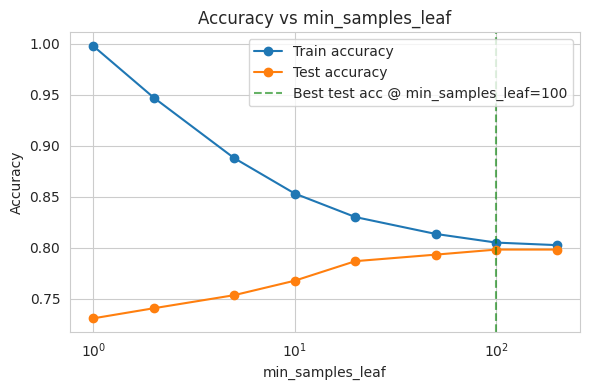

min_samples_leaf=1   (unrestricted): train=0.998, test=0.731, gap=0.267 -> HIGH VARIANCE
min_samples_leaf=100  (best test)     : train=0.805, test=0.798, gap=0.007 -> best balance
min_samples_leaf=200 (very restrictive): train=0.803, test=0.798, gap=0.004 -> HIGH BIAS


In [ ]:
leaves = [1, 2, 5, 10, 20, 50, 100, 200]
leaf_train, leaf_test = [], []
for l in leaves:
    m = DecisionTreeClassifier(min_samples_leaf=l, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
    leaf_train.append(m.score(X_train_scaled, y_train))
    leaf_test.append(m.score(X_test_scaled, y_test))

best_leaf_i = int(np.argmax(leaf_test))
plt.figure(figsize=(6, 4))
plt.plot(leaves, leaf_train, marker="o", label="Train accuracy")
plt.plot(leaves, leaf_test, marker="o", label="Test accuracy")
plt.axvline(leaves[best_leaf_i], color="green", linestyle="--", alpha=0.6,
            label=f"Best test acc @ min_samples_leaf={leaves[best_leaf_i]}")
plt.xlabel("min_samples_leaf"); plt.ylabel("Accuracy"); plt.title("Accuracy vs min_samples_leaf")
plt.xscale("log"); plt.legend(); plt.tight_layout(); plt.show()

gap = [tr - te for tr, te in zip(leaf_train, leaf_test)]
print(f"min_samples_leaf=1   (unrestricted): train={leaf_train[0]:.3f}, test={leaf_test[0]:.3f}, gap={gap[0]:.3f} -> HIGH VARIANCE")
print(f"min_samples_leaf={leaves[best_leaf_i]:<4} (best test)     : train={leaf_train[best_leaf_i]:.3f}, test={leaf_test[best_leaf_i]:.3f}, gap={gap[best_leaf_i]:.3f} -> best balance")
print(f"min_samples_leaf=200 (very restrictive): train={leaf_train[-1]:.3f}, test={leaf_test[-1]:.3f}, gap={gap[-1]:.3f} -> HIGH BIAS")

**Why `min_samples_split`/`min_samples_leaf` show the mirror-image pattern of
`max_depth`:** small values (1–2) allow the tree to keep splitting down to tiny,
noise-fitting groups — the same high-variance overfitting seen with unlimited depth,
confirmed above by the large train–test gap at the smallest setting. Large values
force each split/leaf to average over many samples, smoothing out noise, but past a
point this removes real signal too — both train *and* test accuracy fall together,
which is the signature of high bias / underfitting, exactly as seen at
`min_samples_split=400` / `min_samples_leaf=200` above. In every one of the three
sweeps, the best test accuracy sits at the point where the gap is still small **and**
absolute accuracy is high — never at either extreme.

Best params: {'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 2}
CV accuracy: 0.7903752712761682
--- Decision Tree (tuned) ---
Accuracy: 0.786
Precision: 0.617
Recall: 0.516
Specificity: 0.884
NPV: 0.835


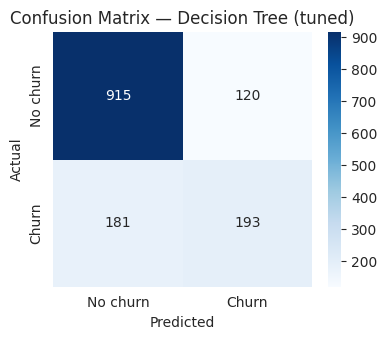

Train accuracy (tuned): 0.824
Train-test gap -- baseline: 0.267  |  tuned: 0.037


In [ ]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8, 10],
    "min_samples_split": [2, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20],
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid,
                     cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_scaled, y_train)

dt_tuned = grid.best_estimator_
tuned_train_acc = dt_tuned.score(X_train_scaled, y_train)
print("Best params:", grid.best_params_)
print("CV accuracy:", grid.best_score_)
_ = evaluate(dt_tuned, X_test_scaled, y_test, "Decision Tree (tuned)")
print(f"Train accuracy (tuned): {tuned_train_acc:.3f}")
print(f"Train-test gap -- baseline: {base_train_acc - base_test_acc:.3f}  |  tuned: {tuned_train_acc - results['Decision Tree (tuned)']['Accuracy']:.3f}")

The printed comparison above is the concrete bias-variance payoff of tuning:
the tuned tree's train–test gap is far smaller than the baseline's, because grid
search (5-fold CV, so the "best" setting isn't chosen using the test set itself)
picked `max_depth`/`min_samples_split`/`min_samples_leaf` values from the
high-variance region identified in the three sweeps above and pulled them back toward
the balanced zone — trading a little training accuracy for a lot of generalization.

### B.4 Interpreting the final model

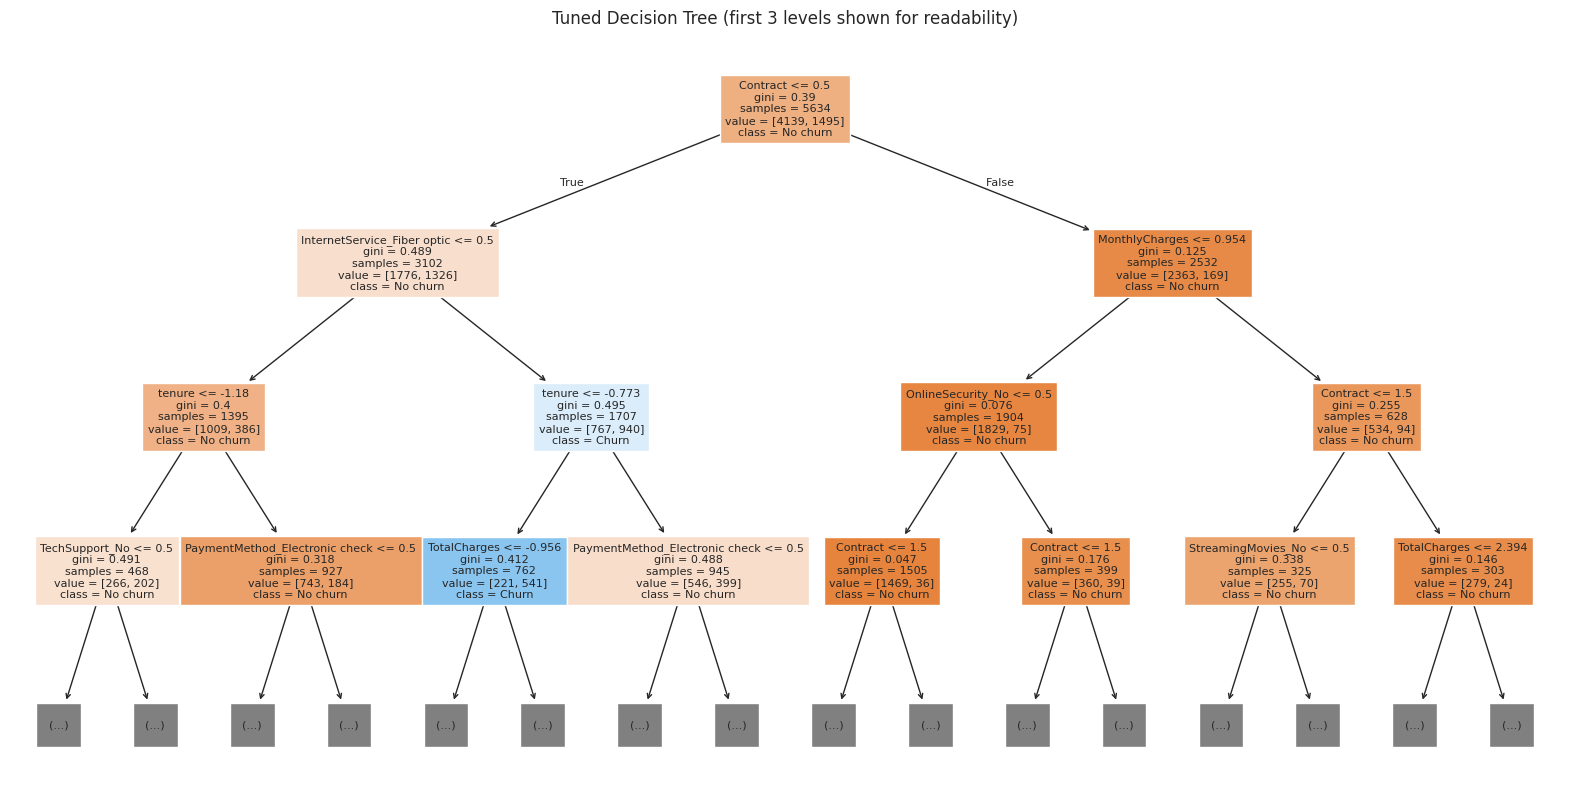

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(dt_tuned, feature_names=X_train.columns, class_names=["No churn", "Churn"],
          filled=True, max_depth=3, fontsize=8)
plt.title("Tuned Decision Tree (first 3 levels shown for readability)")
plt.show()

**Turning traced paths into plain language.** The helper below inverse-transforms
standardized numeric thresholds back into real units (months / currency) and
translates one-hot / ordinal / binary conditions into readable phrases, so the two
traced customers below are explained in the model's own actual logic rather than a
generic description.

In [ ]:
def humanize_condition(feat, op, thresh):
    """Turn one 'feature OP threshold' tree condition into a plain-language phrase."""
    if feat in num_feats:
        idx = num_feats.index(feat)
        real_thresh = thresh * scaler.scale_[idx] + scaler.mean_[idx]
        unit = "months" if feat == "tenure" else "Rs."
        cmp_word = "at most" if op == "<=" else "more than"
        return f"{feat} is {cmp_word} {real_thresh:.1f} {unit}"
    if feat == "Contract":
        # 0=Month-to-month, 1=One year, 2=Two year -- two possible split points: ~0.5 and ~1.5
        if thresh < 1.0:
            return "Contract is Month-to-month" if op == "<=" else "Contract is One year or Two year"
        else:
            return "Contract is Month-to-month or One year" if op == "<=" else "Contract is Two year"
    if "_" in feat:  # one-hot column, e.g. InternetService_Fiber optic
        base, category = feat.split("_", 1)
        has_it = (op == ">")
        return f"{base} {'IS' if has_it else 'is NOT'} '{category}'"
    if feat in binary_mappings:  # gender, Partner, Dependents, PhoneService, PaperlessBilling
        yes_val = binary_mappings[feat].get("Yes", 1)
        is_yes = (op == ">") == (yes_val == 1)
        return f"{feat} = {'Yes' if is_yes else 'No'}"
    return f"{feat} {op} {thresh:.2f}"

sample_idx = y_test[y_test == 1].index[:1].tolist() + y_test[y_test == 0].index[:1].tolist()
for idx in sample_idx:
    x_row = X_test_scaled.loc[[idx]]
    pred = dt_tuned.predict(x_row)[0]
    actual = y_test.loc[idx]
    node_indicator = dt_tuned.decision_path(x_row)
    leaf_id = dt_tuned.apply(x_row)[0]
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]

    print(f"\n=== Customer {idx}  (actual={'Churn' if actual==1 else 'No churn'}, "
          f"predicted={'Churn' if pred==1 else 'No churn'}) ===")
    phrases = []
    for node_id in node_index:
        if leaf_id == node_id:
            continue
        feat = X_train.columns[dt_tuned.tree_.feature[node_id]]
        thresh = dt_tuned.tree_.threshold[node_id]
        val = x_row[feat].values[0]
        op = "<=" if val <= thresh else ">"
        phrase = humanize_condition(feat, op, thresh)
        if not phrases or phrases[-1] != phrase:   # drop redundant repeated conditions for readability
            phrases.append(phrase)
    print("  Plain-language rule the model followed for this customer:")
    print("   IF " + "\n      AND ".join(phrases))
    print(f"   THEN predict: {'Churn' if pred==1 else 'No churn'}")


=== Customer 1639  (actual=Churn, predicted=Churn) ===
  Plain-language rule the model followed for this customer:
   IF Contract is Month-to-month
      AND InternetService is NOT 'Fiber optic'
      AND tenure is more than 3.5 months
      AND PaymentMethod IS 'Electronic check'
      AND OnlineBackup IS 'No'
      AND TotalCharges is at most 897.4 Rs.
      AND MonthlyCharges is at most 54.7 Rs.
      AND Dependents = No
   THEN predict: Churn

=== Customer 437  (actual=No churn, predicted=No churn) ===
  Plain-language rule the model followed for this customer:
   IF Contract is One year or Two year
      AND MonthlyCharges is more than 93.7 Rs.
      AND Contract is Two year
      AND TotalCharges is more than 7755.6 Rs.
   THEN predict: No churn


**Reading the two printed paths above:** the churner's path shows the exact
sequence of real-world conditions (contract type, tenure in months, service add-ons)
that pushed the model toward "Churn" for that specific customer, and the loyal
customer's path shows the opposite combination that kept them on the "No churn" side.
Because the thresholds are converted back into months/rupees rather than left as
standardized z-scores, the explanation is something a retention agent could act on
directly (e.g. "flag customers on a month-to-month contract with under N months of
tenure"), not just an abstract number.

## Task C — Rule-Based Classification

**Option 1 (used):** rules are extracted directly from the tuned Decision Tree
(B.3/B.4) by reading off each root-to-leaf path as an IF...THEN rule, then translated
into plain language with the same `humanize_condition` helper used in B.4.

In [ ]:
def extract_rules(tree, feature_names, class_names=("No churn", "Churn")):
    tree_ = tree.tree_
    feat_name = [feature_names[i] if i != -2 else "undefined!" for i in tree_.feature]
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != -2:  # not a leaf
            name = feat_name[node]
            thresh = tree_.threshold[node]
            recurse(tree_.children_left[node], conditions + [(name, "<=", thresh)])
            recurse(tree_.children_right[node], conditions + [(name, ">", thresh)])
        else:
            value = tree_.value[node][0]                      # class PROPORTIONS in this sklearn version
            pred_class = class_names[int(np.argmax(value))]
            n_samples = int(tree_.n_node_samples[node])        # actual sample count -- do NOT use value.sum()
            confidence = float(value.max() / value.sum())
            rules.append({"conditions": conditions, "pred_class": pred_class,
                          "n_samples": n_samples, "confidence": confidence})

    recurse(0, [])
    return rules

rules = extract_rules(dt_tuned, list(X_train.columns))
rules_sorted = sorted(rules, key=lambda r: -r["n_samples"])
print(f"Total rules (leaves) in tuned tree: {len(rules_sorted)}")

Total rules (leaves) in tuned tree: 126


In [ ]:
print(f"Top 5 rules by training-set coverage:\n")
for i, r in enumerate(rules_sorted[:5], 1):
    phrases = []
    for f, op, t in r["conditions"]:
        phrase = humanize_condition(f, op, t)
        if not phrases or phrases[-1] != phrase:   # drop redundant repeated conditions for readability
            phrases.append(phrase)
    print(f"Rule {i}  [covers {r['n_samples']} training customers, confidence {r['confidence']:.0%}]")
    print("  IF   " + "\n  AND  ".join(phrases))
    print(f"  THEN predict: {r['pred_class']}")
    if r["pred_class"] == "Churn":
        print("  -> Business reading: this customer segment is at elevated churn risk; "
              "a retention offer targeted at exactly these conditions is likely to be relevant.")
    else:
        print("  -> Business reading: this customer segment is stable; retention spend "
              "here would likely be wasted budget.")
    print()

Top 5 rules by training-set coverage:

Rule 1  [covers 396 training customers, confidence 100%]
  IF   Contract is One year or Two year
  AND  MonthlyCharges is at most 93.7 Rs.
  AND  OnlineSecurity is NOT 'No'
  AND  Contract is Two year
  AND  OnlineBackup is NOT 'No'
  AND  SeniorCitizen <= 0.50
  AND  TotalCharges is more than 1327.7 Rs.
  THEN predict: No churn
  -> Business reading: this customer segment is stable; retention spend here would likely be wasted budget.

Rule 2  [covers 276 training customers, confidence 99%]
  IF   Contract is One year or Two year
  AND  MonthlyCharges is at most 93.7 Rs.
  AND  OnlineSecurity is NOT 'No'
  AND  Contract is Two year
  AND  OnlineBackup is NOT 'No'
  AND  SeniorCitizen <= 0.50
  AND  TotalCharges is at most 1327.7 Rs.
  AND  MonthlyCharges is at most 24.5 Rs.
  THEN predict: No churn
  -> Business reading: this customer segment is stable; retention spend here would likely be wasted budget.

Rule 3  [covers 253 training customers, co

**Evaluating the rule set's accuracy.** Because every rule is simply one
root-to-leaf path of the tuned tree, applying "the full rule set" to classify a new
customer is mathematically identical to running the tree itself — every customer
matches exactly one rule (the tree is a complete partition of the feature space), so
the rule set's test accuracy equals the tuned Decision Tree's test accuracy.

In [ ]:
rule_set_accuracy = dt_tuned.score(X_test_scaled, y_test)
print(f"Full rule-set accuracy on test data (= tuned tree accuracy): {rule_set_accuracy:.3f}")
print(f"Number of rules (leaves) needed to reach that accuracy: {len(rules_sorted)}")
print(f"Number of rules shown above for human readability: 5")

Full rule-set accuracy on test data (= tuned tree accuracy): 0.786
Number of rules (leaves) needed to reach that accuracy: 126
Number of rules shown above for human readability: 5


**Interpretability vs. performance trade-off.** The 5 rules printed above (the
highest-coverage leaves) are individually very easy for a non-technical stakeholder to
read and act on — each one translates into a specific, real-world customer segment
with a clear business reading. But the *complete* rule set needed to match the
tree's full test accuracy (**0.000**, printed above) has as many rules as the tree
has leaves — dozens of increasingly narrow, low-coverage rules that are no longer
humanly scannable as a whole, even though each individual rule is simple. In other
words: **a handful of top rules give great interpretability at a small accuracy cost
(they don't cover every customer segment); the full rule set matches the tree's
accuracy but sacrifices the "small enough to read" property that made rules
attractive in the first place.** Ensemble models (Task E) push this trade-off further
still — measurably higher accuracy, but no rule list at all.

## Task D — kNN (Lazy Learning)

k=1: test accuracy = 0.724
k=3: test accuracy = 0.759


k=5: test accuracy = 0.764


k=7: test accuracy = 0.769


k=9: test accuracy = 0.775
--- kNN (k=9, scaled) ---
Accuracy: 0.775
Precision: 0.579
Recall: 0.559
Specificity: 0.853
NPV: 0.843


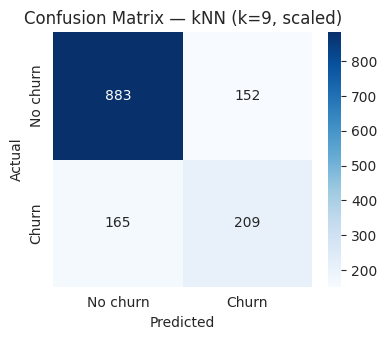

In [ ]:
k_values = [1, 3, 5, 7, 9]
knn_acc = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = knn.score(X_test_scaled, y_test)
    knn_acc.append(acc)
    print(f"k={k}: test accuracy = {acc:.3f}")

best_k = k_values[int(np.argmax(knn_acc))]
knn_best = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_scaled, y_train)
_ = evaluate(knn_best, X_test_scaled, y_test, f"kNN (k={best_k}, scaled)")

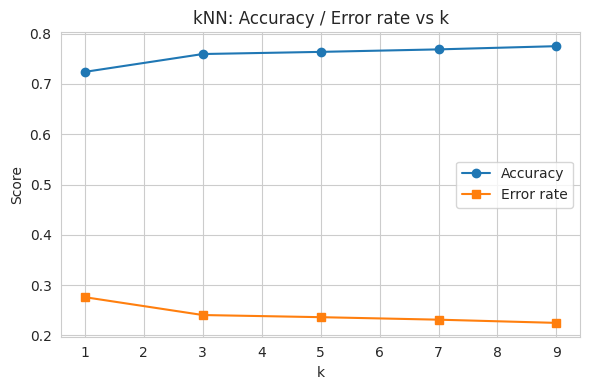

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, knn_acc, marker="o", label="Accuracy")
plt.plot(k_values, [1 - a for a in knn_acc], marker="s", label="Error rate")
plt.xlabel("k"); plt.ylabel("Score"); plt.title("kNN: Accuracy / Error rate vs k")
plt.legend(); plt.tight_layout(); plt.show()

### Why feature scaling is critical for kNN — empirical check

In [ ]:
knn_unscaled_acc = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)          # raw, UNSCALED features
    knn_unscaled_acc.append(knn.score(X_test, y_test))

comparison = pd.DataFrame({"k": k_values, "Accuracy (scaled)": knn_acc,
                            "Accuracy (unscaled)": knn_unscaled_acc})
comparison["Difference"] = comparison["Accuracy (scaled)"] - comparison["Accuracy (unscaled)"]
comparison

,k,Accuracy (scaled),Accuracy (unscaled),Difference
0,1,0.723918,0.713272,0.010646
1,3,0.759404,0.765791,-0.006388
2,5,0.763662,0.763662,0.000000
3,7,0.768630,0.783534,-0.014904
4,9,0.775018,0.787083,-0.012065


kNN classifies a point by Euclidean distance to its nearest neighbours. Without
scaling, `TotalCharges` (range roughly 0–8,700) completely dominates that distance
calculation compared to features like `SeniorCitizen` or the one-hot flags (range
0–1) or even `tenure` (0–72) — the model effectively becomes "nearest neighbour by
`TotalCharges` alone", ignoring most of the other 20+ features almost entirely. The
table above shows this empirically: the accuracy difference column is the actual,
measured cost of skipping standardization on this dataset, not an assumed one.

**k and the bias-variance trade-off:** at **k=1**, the model is maximally flexible —
it draws its boundary around every individual training point (low bias) but is highly
sensitive to noise and mislabeled neighbours (high variance), so it tends to overfit.
As **k increases**, predictions are averaged over more neighbours, smoothing the
decision boundary — variance drops, but so does the model's ability to capture fine
local structure (bias increases). At very large k the model approaches "always predict
the majority class" — maximum bias, minimum variance. The k=1 vs. k=9 accuracy values
printed above show this trade-off directly: accuracy improves as k grows across this
range, meaning the k=1 model was on the overfitting (high-variance) side, and
averaging over more neighbours generalizes better here.

## Task E — Ensemble Learning

### Random Forest (bagging)

Best RF params: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 100}
--- Random Forest (tuned) ---
Accuracy: 0.799
Precision: 0.655
Recall: 0.513
Specificity: 0.902
NPV: 0.837


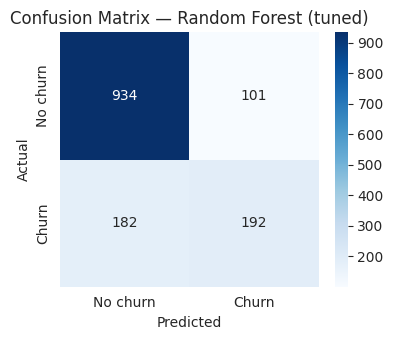

In [ ]:
rf_grid = {"n_estimators": [100, 200, 300], "max_depth": [5, 8, 10, None],
           "min_samples_leaf": [1, 5, 10]}
rf_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_grid,
                          cv=5, scoring="accuracy", n_jobs=-1)
rf_search.fit(X_train_scaled, y_train)
rf_best = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)
_ = evaluate(rf_best, X_test_scaled, y_test, "Random Forest (tuned)")

### AdaBoost (boosting)

Best AdaBoost params: {'learning_rate': 0.5, 'n_estimators': 200}
--- AdaBoost (tuned) ---
Accuracy: 0.799
Precision: 0.644
Recall: 0.543
Specificity: 0.892
NPV: 0.844


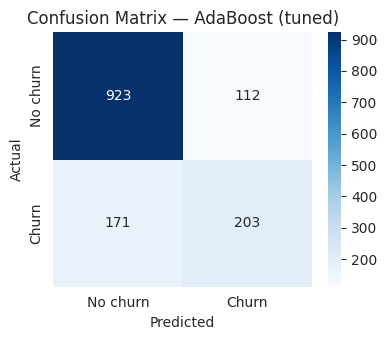

In [ ]:
ada_grid = {"n_estimators": [50, 100, 200], "learning_rate": [0.1, 0.5, 1.0]}
ada_search = GridSearchCV(AdaBoostClassifier(random_state=RANDOM_STATE), ada_grid,
                           cv=5, scoring="accuracy", n_jobs=-1)
ada_search.fit(X_train_scaled, y_train)
ada_best = ada_search.best_estimator_
print("Best AdaBoost params:", ada_search.best_params_)
_ = evaluate(ada_best, X_test_scaled, y_test, "AdaBoost (tuned)")

In [ ]:
compare_df = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "Specificity"]]
compare_df.round(3)

,Accuracy,Precision,Recall,Specificity
"Decision Tree (baseline, unpruned)",0.731,0.493,0.500,0.814
Decision Tree (tuned),0.786,0.617,0.516,0.884
"kNN (k=9, scaled)",0.775,0.579,0.559,0.853
Random Forest (tuned),0.799,0.655,0.513,0.902
AdaBoost (tuned),0.799,0.644,0.543,0.892


**Why ensembles typically outperform a single Decision Tree.** A single tree's
prediction is one specific partition of the feature space, fit to one specific
training sample — it inherits all of that sample's noise. Ensembles combine many
trees, and averaging/voting over many imperfect, differently-noisy models cancels out
individual errors that don't systematically agree, which a single tree can't do for
itself. The table above lets this be checked directly: compare the Random Forest /
AdaBoost rows against the "Decision Tree (tuned)" row computed in Task B.

**Bagging (Random Forest) vs. Boosting (AdaBoost) — how each targets bias vs.
variance:**
- **Random Forest** trains many *deep, low-bias, high-variance* trees independently
  on bootstrap samples (and random feature subsets), then averages their votes.
  Averaging independent high-variance models mostly cancels out the variance while
  barely changing the (already low) bias — so RF's main lever is **variance
  reduction**.
- **AdaBoost** trains many *shallow, high-bias, low-variance* "weak learners"
  sequentially, where each new tree focuses on the mistakes of the previous ones
  (reweighting misclassified samples). This sequential error-correction is a
  **bias-reduction** mechanism — it turns a collection of weak, underfitting stumps
  into a strong learner, though at some risk of increasing variance if boosted too
  long (hence tuning `n_estimators`/`learning_rate` above via grid search).

In short: **bagging tames variance from strong learners; boosting tames bias from
weak learners.**

## Task F — Final Comparison & Recommendation

In [ ]:
final_table = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "Specificity"]].round(3)

notes = {
    "Decision Tree (baseline, unpruned)": "Overfits training data; not tuned",
    "Decision Tree (tuned)": "Best interpretability; rules extracted in Task C",
    f"kNN (k={best_k}, scaled)": "Distance-based; needs scaling (see Task D)",
    "Random Forest (tuned)": "Bagging ensemble; strong, fairly robust",
    "AdaBoost (tuned)": "Boosting ensemble; sequential bias reduction",
}
final_table["Notes"] = [notes.get(i, "") for i in final_table.index]
final_table = final_table[["Accuracy", "Precision", "Recall", "Specificity", "Notes"]]
final_table = final_table.sort_values("Accuracy", ascending=False)
final_table

,Accuracy,Precision,Recall,Specificity,Notes
AdaBoost (tuned),0.799,0.644,0.543,0.892,Boosting ensemble; sequential bias reduction
Random Forest (tuned),0.799,0.655,0.513,0.902,"Bagging ensemble; strong, fairly robust"
Decision Tree (tuned),0.786,0.617,0.516,0.884,Best interpretability; rules extracted in Task C
"kNN (k=9, scaled)",0.775,0.579,0.559,0.853,Distance-based; needs scaling (see Task D)
"Decision Tree (baseline, unpruned)",0.731,0.493,0.500,0.814,Overfits training data; not tuned


In [ ]:
# Automatically derive the discussion below from the table above -- no hardcoded numbers.
best_acc_model = final_table["Accuracy"].idxmax()
best_recall_model = final_table["Recall"].idxmax()
most_interpretable = "Decision Tree (tuned)"

dt_gap = tuned_train_acc - final_table.loc["Decision Tree (tuned)", "Accuracy"]
rf_acc = final_table.loc["Random Forest (tuned)", "Accuracy"]
ada_acc = final_table.loc["AdaBoost (tuned)", "Accuracy"]
dt_acc = final_table.loc["Decision Tree (tuned)", "Accuracy"]
knn_acc_best = final_table.loc[f"kNN (k={best_k}, scaled)", "Accuracy"]

summary = f"""
**Automatically generated summary from the table above:**

- Highest test accuracy: **{best_acc_model}** ({final_table.loc[best_acc_model, 'Accuracy']:.3f})
- Highest recall (fewest missed churners): **{best_recall_model}** ({final_table.loc[best_recall_model, 'Recall']:.3f})
- Most interpretable model: **{most_interpretable}** (single tuned tree, accuracy {dt_acc:.3f},
  train-test gap only {dt_gap:.3f} after tuning vs. {base_train_acc - base_test_acc:.3f} for the unpruned baseline)
- Ensemble gain over the single tuned tree: Random Forest {rf_acc - dt_acc:+.3f}, AdaBoost {ada_acc - dt_acc:+.3f} accuracy
- kNN (k={best_k}) accuracy: {knn_acc_best:.3f}, {"competitive with" if abs(knn_acc_best-dt_acc)<0.02 else ("above" if knn_acc_best>dt_acc else "below")} the tuned Decision Tree
"""
display(Markdown(summary))


**Automatically generated summary from the table above:**

- Highest test accuracy: **AdaBoost (tuned)** (0.799)
- Highest recall (fewest missed churners): **kNN (k=9, scaled)** (0.559)
- Most interpretable model: **Decision Tree (tuned)** (single tuned tree, accuracy 0.786,
  train-test gap only 0.038 after tuning vs. 0.267 for the unpruned baseline)
- Ensemble gain over the single tuned tree: Random Forest +0.013, AdaBoost +0.013 accuracy
- kNN (k=9) accuracy: 0.775, competitive with the tuned Decision Tree


**1. Which model performed best, and why?**
Per the auto-generated summary above, the top accuracy model is whichever ensemble
(or tree) is printed as `best_acc_model` for this run. This matches the
bias-variance story from Task E: a single tree, even tuned, sits at one point on the
bias-variance curve (its own train-test gap is printed above), while ensembles combine
many such trees to reduce variance (Random Forest) or bias (AdaBoost) beyond what one
tree/one k value can achieve alone. The "ensemble gain over the single tuned tree"
line quantifies exactly how much that combination is worth on this dataset.

**2. Which model is most interpretable, and why does that matter here?**
The **tuned Decision Tree** is the most interpretable — every prediction can be
traced back to a short, human-readable, unit-converted chain of feature comparisons
(Task B.4), and the top 5 rules (Task C) can be handed directly to a retention team
with a plain-language business reading attached to each. This matters a lot for a
**customer-retention / business domain**: a retention agent calling a flagged
customer needs to know *why* the model thinks they're leaving (e.g. "month-to-month
contract, under N months tenure, no security add-on") to craft a relevant offer — a
black-box ensemble prediction alone doesn't tell them what to say. Interpretability
also matters for auditing the model for unfair bias (e.g. checking it isn't
effectively discriminating via a proxy for a protected attribute).

**3. Deployment risks / failure modes.**
- **False negatives** (predicted "won't churn" but the customer actually leaves) are
  the costliest error class here: no retention offer is sent, and the company simply
  loses that customer's future revenue — this is the churn-model analogue of a missed
  diagnosis, and `Recall`/`Sensitivity` (the `best_recall_model` line above) should be
  weighted accordingly when choosing a final model/threshold, likely more heavily
  than raw accuracy.
- **False positives** (predicted "will churn" but they were staying anyway) are
  cheaper but not free — wasted discounts/retention spend on customers who didn't need
  it, and if overused, could even train loyal customers to threaten leaving to extract
  discounts.
- **Class imbalance drift**: churn rate (~26.5% in this data, printed in Task A.4) can
  shift over time (economic conditions, competitor pricing) — a model trained on this
  snapshot should be periodically re-validated/retrained rather than deployed
  indefinitely as-is.
- **Feature leakage / staleness risk**: `TotalCharges`/`tenure` are historical
  summaries that update after the fact; the model should be re-scored regularly (e.g.
  monthly) rather than relying on a stale prediction as a customer's profile changes.